In [1]:
### to create mba version of the plot using the new code

In [2]:
## automatically reload 
%reload_ext autoreload
%autoreload 2

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import NEOMOD3 as nm3
import NEOfaster as nf
import neoscore as nsc
import S3Marray as sm
import S3M_fullversion as smfull
import trojans as tjn
import neoonlyS3M as neo3m

In [5]:
s3m = sm.define_s3m()

['S1_00.s3m', 'S1_01.s3m', 'S1_02.s3m', 'S1_03.s3m', 'S1_04.s3m', 'S1_05.s3m', 'S1_06.s3m', 'S1_07.s3m', 'S1_08.s3m', 'S1_09.s3m', 'S1_10.s3m', 'S1_11.s3m', 'S1_12.s3m', 'S1_13.s3m']
The final df is done.


In [6]:
s3m,array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m = sm.s3m_array(s3m)

In [7]:
scorer_mba_s3m = nsc.NEOMODScorer(array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m)

Starting computation...


Computing vlambda grid: 100%|██████████| 31/31 [1:38:07<00:00, 189.92s/it]


Computation complete!


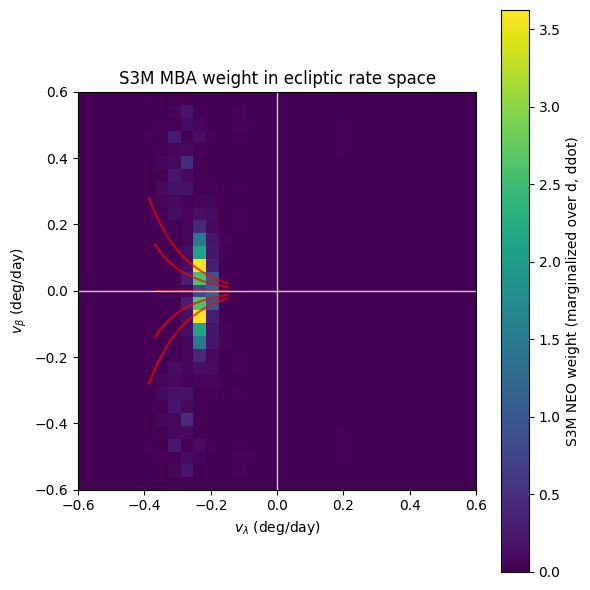

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import neoscore as nsc
from tqdm import tqdm

# Observation params
obstime_str = "2025-09-23T00:00:00"
ra0_deg, dec0_deg = 0.0, 0.0
mag = 20.0

def comp_sum_with_scorer():
    """
    Compute marginalized weights over (vlambda, vbeta) grid using the scorer.
    """
    N_rate = 31
    vlam_min, vlam_max = -0.6, 0.6
    vbet_min, vbet_max = -0.6, 0.6
    vlam_vals = np.linspace(vlam_min, vlam_max, N_rate)
    vbet_vals = np.linspace(vbet_min, vbet_max, N_rate)
    
    K = np.zeros((len(vbet_vals), len(vlam_vals)), dtype=float)
    
    
    for i, vlam in enumerate(tqdm(vlam_vals, desc="Computing vlambda grid")):
        for j, vbet in enumerate(vbet_vals):
            # Convert ecliptic rates to RA/Dec rates
            dra, ddec = nsc.ecliptic_rates_to_radec_rates1(
                ra0_deg, dec0_deg, vlam, vbet, obstime_str
            )
            
            # Use the scorer's marginalization method
            w_int = scorer_mba_s3m.marginalize_over_distance(
                obstime_str=obstime_str,
                ra_deg=ra0_deg,
                dec_deg=dec0_deg,
                dra_deg_per_day=dra,
                ddec_deg_per_day=ddec,
                mag=mag
            )
            
            K[j, i] = w_int
    
    extent = [vlam_vals[0], vlam_vals[-1], vbet_vals[0], vbet_vals[-1]]
    return K, extent, vlam_vals, vbet_vals

# Compute the grid
print("Starting computation...")
K, extent, vlam_vals, vbet_vals = comp_sum_with_scorer()
print("Computation complete!")

# Prediction function 
vE_deg_per_day = 0.986  # Earth's orbital speed

def prediction_vlam_vbet(R_au, i_deg, phi_deg, beta_deg=0.0):
    """Predict ecliptic rates for given orbital parameters."""
    i = np.deg2rad(i_deg)
    phi = np.deg2rad(phi_deg)
    beta = np.deg2rad(beta_deg)
    
    theta = phi - np.arcsin(np.sin(phi) / R_au)
    Delta = np.sqrt(R_au**2 + 1.0 - 2.0 * R_au * np.cos(theta))
    
    v_factor = vE_deg_per_day / np.sqrt(R_au)
    vx = v_factor * np.cos(i) * np.sin(theta)
    vy = v_factor * np.cos(i) * np.cos(theta)
    vz = v_factor * np.sin(i)
    
    vlam = (np.sin(phi) * vx + np.cos(phi) * (vy - vE_deg_per_day)) / Delta
    vbet = (-np.sin(beta) * np.cos(phi) * vx
            + np.sin(beta) * np.sin(phi) * (vy - vE_deg_per_day)
            + np.cos(beta) * vz) / Delta
    
    return vlam, vbet

# Generate prediction curves for different inclinations
phi_deg = 0.0  # opposition
beta_deg = 0.0  # on the ecliptic
i_list = np.arange(-10.0, 15.0, 5.0)  # -10, -5, 0, 5, 10
R_vals = np.linspace(1.5, 4.5, 800)  # AU

i_lines = []
for i_deg in i_list:
    vlam_arr = []
    vbet_arr = []
    for R in R_vals:
        vlam, vbet = prediction_vlam_vbet(R, i_deg, phi_deg, beta_deg)
        vlam_arr.append(vlam)
        vbet_arr.append(vbet)
    i_lines.append((np.array(vlam_arr), np.array(vbet_arr), i_deg))


plt.figure(figsize=(6.0, 6.0))
im = plt.imshow(K, origin="lower", extent=extent, cmap="viridis", aspect="equal")
plt.colorbar(label="S3M NEO weight (marginalized over d, ddot)")

# Plot prediction curves
for vlam_arr, vbet_arr, i_deg in i_lines:
    plt.plot(vlam_arr, vbet_arr, 'r-', lw=1.5, alpha=0.7, 
             label=f'i={i_deg}°' if i_deg == i_list[0] else '')

plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
plt.xlim(-0.6, 0.6)
plt.ylim(-0.6, 0.6)
plt.title("S3M MBA weight in ecliptic rate space")
plt.tight_layout()
plt.show()

Chosen pixel (nearest grid cell):
  v_lambda = -0.2400 deg/day  (target -0.25)
  v_beta   = 0.0800 deg/day  (target 0.1)
  K value  = 3.579200e+00

Converted RA/Dec rates:
  dRA/dt  = -0.252018 deg/day
  dDec/dt = -0.022068 deg/day


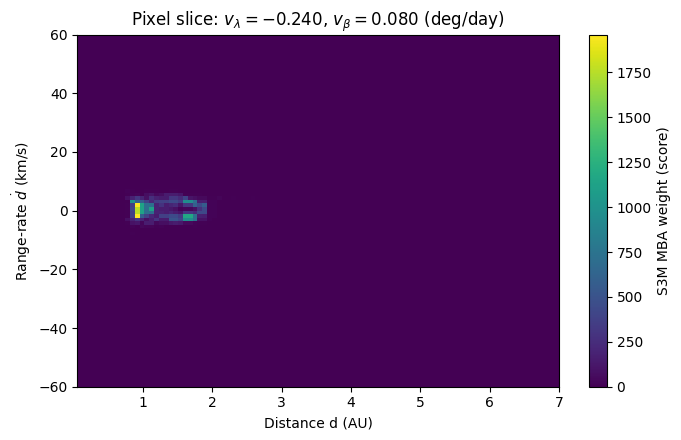

In [34]:
# Choose target pixel in (vlam, vbet)

vlam_target = -0.25
vbet_target =  0.10

i_vlam = int(np.argmin(np.abs(vlam_vals - vlam_target)))
j_vbet = int(np.argmin(np.abs(vbet_vals - vbet_target)))

vlam_pix = float(vlam_vals[i_vlam])
vbet_pix = float(vbet_vals[j_vbet])

print("Chosen pixel (nearest grid cell):")
print(f"  v_lambda = {vlam_pix:.4f} deg/day  (target {vlam_target})")
print(f"  v_beta   = {vbet_pix:.4f} deg/day  (target {vbet_target})")
print(f"  K value  = {K[j_vbet, i_vlam]:.6e}")

# Convert this pixel in ecliptic-rate  -> RA/Dec rates

dra_pix, ddec_pix = nsc.ecliptic_rates_to_radec_rates1(
    ra0_deg, dec0_deg, vlam_pix, vbet_pix, obstime_str
)

print("\nConverted RA/Dec rates:")
print(f"  dRA/dt  = {dra_pix:.6f} deg/day")
print(f"  dDec/dt = {ddec_pix:.6f} deg/day")

# Scan a (d, ddot) grid using scorer 

d_vals    = np.linspace(0.05, 7.0, 100)      
ddot_vals = np.linspace(-60.0, 60.0, 100)   

W_dd = np.zeros((len(ddot_vals), len(d_vals)), dtype=float)

for j_dd, ddot in enumerate(ddot_vals):
    for i_d, d in enumerate(d_vals):
        out = scorer_mba_s3m.compute_score(
            obstime_str=obstime_str,
            ra_deg=ra0_deg,
            dec_deg=dec0_deg,
            dra_deg_per_day=dra_pix,
            ddec_deg_per_day=ddec_pix,
            mag=mag,
            d_au=float(d),
            ddot_kms=float(ddot),
        )
        W_dd[j_dd, i_d] = out["score"]


# Plot d vs ddot for this pixel

plt.figure(figsize=(7, 4.5))
im = plt.imshow(
    W_dd,
    origin="lower",
    aspect="auto",
    extent=[d_vals[0], d_vals[-1], ddot_vals[0], ddot_vals[-1]],
    cmap="viridis",
)
plt.colorbar(label="S3M MBA weight (score)")

plt.xlabel("Distance d (AU)")
plt.ylabel(r"Range-rate $\dot d$ (km/s)")
plt.title(rf"Pixel slice: $v_\lambda={vlam_pix:.3f}$, $v_\beta={vbet_pix:.3f}$ (deg/day)")

plt.tight_layout()
plt.show()


7 chosen pixels (from K grid):
top-yellow        i= 9 j=17   vlam=-0.2400  vbet= 0.0800   K=3.579e+00
bottom-yellow     i= 9 j=13   vlam=-0.2400  vbet=-0.0800   K=3.623e+00
left-of-top       i= 8 j=17   vlam=-0.2800  vbet= 0.0800   K=1.426e-01
right-of-top      i=10 j=17   vlam=-0.2000  vbet= 0.0800   K=2.810e-01
left-of-bottom    i= 8 j=13   vlam=-0.2800  vbet=-0.0800   K=1.426e-01
right-of-bottom   i=10 j=13   vlam=-0.2000  vbet=-0.0800   K=2.810e-01
center (vbeta~0)  i= 9 j=15   vlam=-0.2400  vbet= 0.0000   K=8.074e-01


Pixels: 100%|██████████| 7/7 [07:09<00:00, 61.31s/it]
/tmp/ipykernel_1723882/706674810.py:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


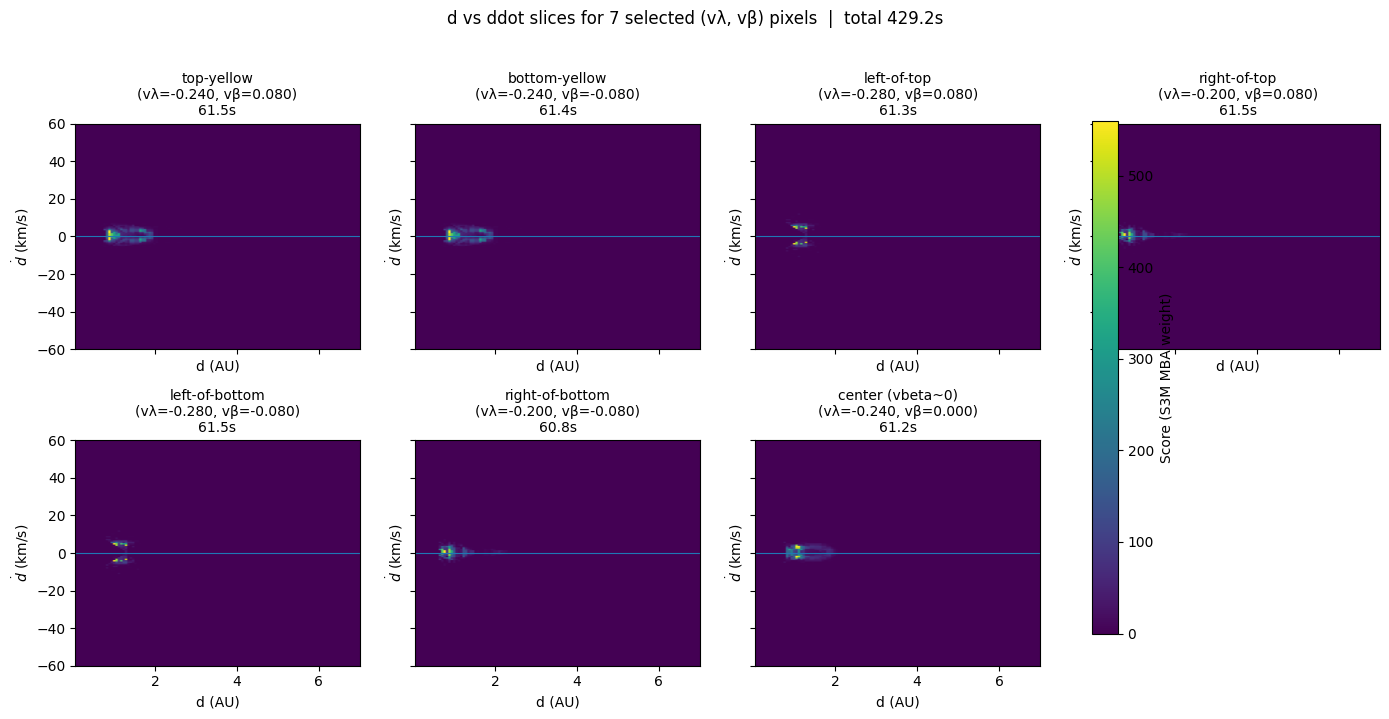

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

# compute (d, ddot) weight map for one (vlam, vbet) pixel
# Uses scorer.compute_score() 

def dd_map_for_pixel(vlam_pix, vbet_pix, *,
                     scorer, ra0_deg, dec0_deg, obstime_str, mag,
                     d_min=0.05, d_max=7.0, Nd=120,
                     v_min=-60.0, v_max=60.0, Nv=160):

    
    dra_pix, ddec_pix = nsc.ecliptic_rates_to_radec_rates1(
        ra0_deg, dec0_deg, float(vlam_pix), float(vbet_pix), obstime_str
    )


    d_vals = np.linspace(d_min, d_max, Nd)
    ddot_vals = np.linspace(v_min, v_max, Nv)

    W_dd = np.zeros((Nv, Nd), dtype=float)

    
    for j_dd, ddot in enumerate(ddot_vals):
        for i_d, d in enumerate(d_vals):
            out = scorer.compute_score(
                obstime_str=obstime_str,
                ra_deg=ra0_deg,
                dec_deg=dec0_deg,
                dra_deg_per_day=float(dra_pix),
                ddec_deg_per_day=float(ddec_pix),
                mag=float(mag),
                d_au=float(d),
                ddot_kms=float(ddot),
            )
            W_dd[j_dd, i_d] = out["score"]

    return W_dd, d_vals, ddot_vals, dra_pix, ddec_pix



#7 pixel selection 

vlam_target = -0.25
i0 = int(np.argmin(np.abs(vlam_vals - vlam_target)))
j_center = int(np.argmin(np.abs(vbet_vals - 0.0)))

col = K[:, i0].copy()
j_top = int(np.argmax(col[j_center+1:]) + (j_center+1))
j_bot = int(np.argmax(col[:j_center]))

iL = max(i0 - 1, 0)
iR = min(i0 + 1, len(vlam_vals) - 1)

pixel_ijs = [
    ("top-yellow",        i0, j_top),
    ("bottom-yellow",     i0, j_bot),
    ("left-of-top",       iL, j_top),
    ("right-of-top",      iR, j_top),
    ("left-of-bottom",    iL, j_bot),
    ("right-of-bottom",   iR, j_bot),
    ("center (vbeta~0)",  i0, j_center),
]

print("7 chosen pixels (from K grid):")
for name, i, j in pixel_ijs:
    print(f"{name:16s}  i={i:2d} j={j:2d}   vlam={vlam_vals[i]: .4f}  vbet={vbet_vals[j]: .4f}   K={K[j,i]:.3e}")



#Compute + plot with tqdm timing

d_min, d_max = 0.05, 7.0
v_min, v_max = -60.0, 60.0


Nd, Nv = 120, 160

fig, axes = plt.subplots(2, 4, figsize=(14, 7), sharex=True, sharey=True)
axes = axes.ravel()

t0 = time.time()

last_im = None
for ax_i, (name, i, j) in enumerate(tqdm(pixel_ijs, desc="Pixels")):
    vlam_pix = float(vlam_vals[i])
    vbet_pix = float(vbet_vals[j])

    t_pix0 = time.time()
    W_dd, d_vals, ddot_vals, dra_pix, ddec_pix = dd_map_for_pixel(
        vlam_pix, vbet_pix,
        scorer=scorer_mba_s3m,
        ra0_deg=ra0_deg, dec0_deg=dec0_deg,
        obstime_str=obstime_str, mag=mag,
        d_min=d_min, d_max=d_max, Nd=Nd,
        v_min=v_min, v_max=v_max, Nv=Nv
    )
    t_pix = time.time() - t_pix0

    ax = axes[ax_i]
    last_im = ax.imshow(
        W_dd,
        origin="lower",
        aspect="auto",
        extent=[d_vals[0], d_vals[-1], ddot_vals[0], ddot_vals[-1]],
        cmap="viridis",
    )
    ax.set_title(
        f"{name}\n(vλ={vlam_pix:.3f}, vβ={vbet_pix:.3f})\n{t_pix:.1f}s",
        fontsize=10
    )
    ax.axhline(0.0, lw=0.8)

# hide the 8th (unused) panel
axes[-1].axis("off")

for ax in axes[:7]:
    ax.set_xlabel("d (AU)")
    ax.set_ylabel(r"$\dot d$ (km/s)")

cbar = fig.colorbar(last_im, ax=axes.tolist(), shrink=0.95)
cbar.set_label("Score (S3M MBA weight)")

t_total = time.time() - t0
fig.suptitle(f"d vs ddot slices for 7 selected (vλ, vβ) pixels  |  total {t_total:.1f}s", y=1.02)
plt.tight_layout()
plt.show()


In [35]:
#Select the 7 pixels
import numpy as np

vlam_target = -0.25
i0 = int(np.argmin(np.abs(vlam_vals - vlam_target)))
j_center = int(np.argmin(np.abs(vbet_vals - 0.0)))

col = K[:, i0].copy()
j_top = int(np.argmax(col[j_center+1:]) + (j_center+1))
j_bot = int(np.argmax(col[:j_center]))

iL = max(i0 - 1, 0)
iR = min(i0 + 1, len(vlam_vals) - 1)

pixel_ijs = [
    ("top-yellow",        i0, j_top),
    ("bottom-yellow",     i0, j_bot),
    ("left-of-top",       iL, j_top),
    ("right-of-top",      iR, j_top),
    ("left-of-bottom",    iL, j_bot),
    ("right-of-bottom",   iR, j_bot),
    ("center (vbeta~0)",  i0, j_center),
]

print("7 chosen pixels (from K grid):")
for name, i, j in pixel_ijs:
    print(
        f"{name:16s}  "
        f"i={i:2d} j={j:2d}  "
        f"vlam={vlam_vals[i]: .4f}  "
        f"vbet={vbet_vals[j]: .4f}  "
        f"K={K[j,i]:.3e}"
    )


7 chosen pixels (from K grid):
top-yellow        i= 9 j=17  vlam=-0.2400  vbet= 0.0800  K=3.579e+00
bottom-yellow     i= 9 j=13  vlam=-0.2400  vbet=-0.0800  K=3.623e+00
left-of-top       i= 8 j=17  vlam=-0.2800  vbet= 0.0800  K=1.426e-01
right-of-top      i=10 j=17  vlam=-0.2000  vbet= 0.0800  K=2.810e-01
left-of-bottom    i= 8 j=13  vlam=-0.2800  vbet=-0.0800  K=1.426e-01
right-of-bottom   i=10 j=13  vlam=-0.2000  vbet=-0.0800  K=2.810e-01
center (vbeta~0)  i= 9 j=15  vlam=-0.2400  vbet= 0.0000  K=8.074e-01


In [36]:
# d–ddot map 
from tqdm import tqdm

def dd_map_for_pixel(
    vlam_pix, vbet_pix,
    *,
    scorer,
    ra0_deg, dec0_deg, obstime_str, mag,
    d_min=0.05, d_max=7.0, Nd=120,
    v_min=-60.0, v_max=60.0, Nv=160
):
    # Convert ecliptic → RA/Dec rates
    dra_pix, ddec_pix = nsc.ecliptic_rates_to_radec_rates1(
        ra0_deg, dec0_deg,
        float(vlam_pix), float(vbet_pix),
        obstime_str
    )

    d_vals = np.linspace(d_min, d_max, Nd)
    ddot_vals = np.linspace(v_min, v_max, Nv)

    W_dd = np.zeros((Nv, Nd), dtype=float)

    for j_dd, ddot in enumerate(tqdm(ddot_vals, leave=False)):
        for i_d, d in enumerate(d_vals):
            out = scorer.compute_score(
                obstime_str=obstime_str,
                ra_deg=ra0_deg,
                dec_deg=dec0_deg,
                dra_deg_per_day=float(dra_pix),
                ddec_deg_per_day=float(ddec_pix),
                mag=float(mag),
                d_au=float(d),
                ddot_kms=float(ddot),
            )
            W_dd[j_dd, i_d] = out["score"]

    return W_dd, d_vals, ddot_vals, dra_pix, ddec_pix


In [60]:
# Run one pixel
# 0 = top yellow
# 1 = bottom yellow
# 2 = left top
# 3 = righ top
# 4 = left bottom
# 5 = right bottom
# 6 = center

name, i, j = pixel_ijs[5]   # change index 0–6 

vlam_pix = float(vlam_vals[i])
vbet_pix = float(vbet_vals[j])

print(f"Running pixel: {name}")
print(f"vlam={vlam_pix:.4f}, vbet={vbet_pix:.4f}")

W_dd, d_vals, ddot_vals, dra_pix, ddec_pix = dd_map_for_pixel(
    vlam_pix, vbet_pix,
    scorer=scorer_mba_s3m,
    ra0_deg=ra0_deg,
    dec0_deg=dec0_deg,
    obstime_str=obstime_str,
    mag=mag,
)

print("Done.")


Running pixel: right-of-bottom
vlam=-0.2000, vbet=-0.0800


Done.


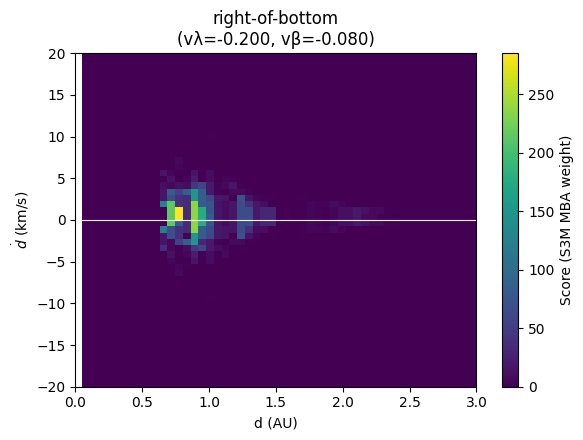

In [62]:
# Plot one pixel
import matplotlib.pyplot as plt
import os

# uncomment line to save images again
# makes folder and places images there
#outdir = "pixel_ddot_plots"
#os.makedirs(outdir, exist_ok=True)


plt.figure(figsize=(6, 4.5))
im = plt.imshow(
    W_dd,
    origin="lower",
    aspect="auto",
    extent=[d_vals[0], d_vals[-1], ddot_vals[0], ddot_vals[-1]],
    cmap="viridis",
)

plt.colorbar(label="Score (S3M MBA weight)")
plt.axhline(0.0, color="w", lw=0.8)

plt.xlabel("d (AU)")
plt.ylabel(r"$\dot d$ (km/s)")
plt.title(f"{name}\n(vλ={vlam_pix:.3f}, vβ={vbet_pix:.3f})")
plt.xlim(0,3)
plt.ylim(-20,20)
plt.tight_layout()

# save figure
#fname = f"{outdir}/ddot_map_{name.replace(' ', '_')}_vlam{vlam_pix:+.3f}_vbet{vbet_pix:+.3f}.png"
#plt.savefig(fname, dpi=200)


plt.show()

#print(f"Saved to {fname}")

In [46]:
# Run all 7 pixels (is slow ~5-10mins)


results = {}

for name, i, j in pixel_ijs:
    print(f"\nRunning {name}...")
    vlam_pix = float(vlam_vals[i])
    vbet_pix = float(vbet_vals[j])

    W_dd, d_vals, ddot_vals, dra_pix, ddec_pix = dd_map_for_pixel(
        vlam_pix, vbet_pix,
        scorer=scorer_mba_s3m,
        ra0_deg=ra0_deg,
        dec0_deg=dec0_deg,
        obstime_str=obstime_str,
        mag=mag,
    )

    results[name] = dict(
        W_dd=W_dd,
        d_vals=d_vals,
        ddot_vals=ddot_vals,
        vlam=vlam_pix,
        vbet=vbet_pix,
    )

print("All pixels complete.")



Running top-yellow...



Running bottom-yellow...



Running left-of-top...



Running right-of-top...



Running left-of-bottom...



Running right-of-bottom...



Running center (vbeta~0)...


All pixels complete.


/tmp/ipykernel_1723882/4116393053.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  W_d = np.trapz(W_dd, ddot_vals, axis=0)  # shape: (Nd,)


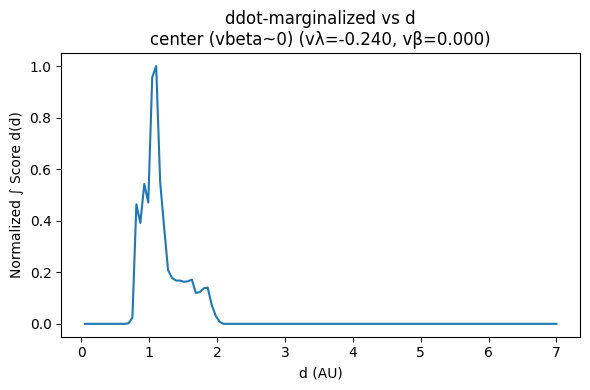

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# ddot-marginalize (integrate over ddot axis)
W_d = np.trapz(W_dd, ddot_vals, axis=0)  # shape: (Nd,)

# optional: normalize for shape comparison
W_d_norm = W_d / (W_d.max() if W_d.max() > 0 else 1.0)

plt.figure(figsize=(6,4))
plt.plot(d_vals, W_d_norm)
plt.xlabel("d (AU)")
plt.ylabel("Normalized ∫ Score d(ḋ)")
plt.title(f"ddot-marginalized vs d\n{name} (vλ={vlam_pix:.3f}, vβ={vbet_pix:.3f})")
plt.tight_layout()
plt.show()


/tmp/ipykernel_1723882/4238033825.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  W_d_i = np.trapz(W_dd_i, ddot_vals_i, axis=0)


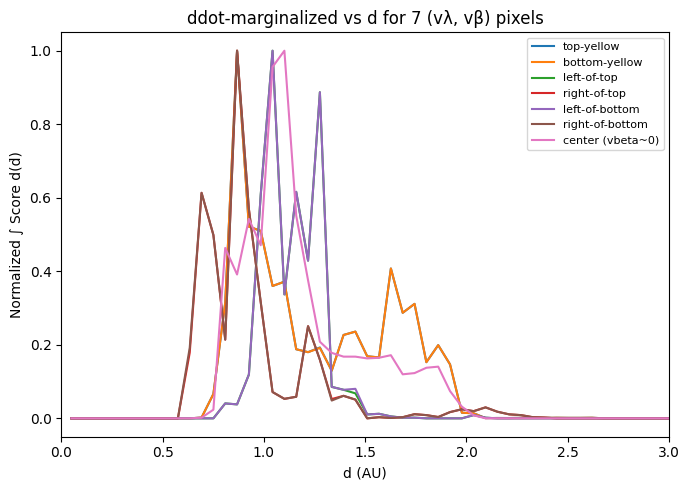

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

curves = {}

# If you have `results` from the batch cell, use it
if "results" in globals() and isinstance(results, dict) and len(results) > 0:
    for key, item in results.items():
        W_dd_i = item["W_dd"]
        d_vals_i = item["d_vals"]
        ddot_vals_i = item["ddot_vals"]
        W_d_i = np.trapz(W_dd_i, ddot_vals_i, axis=0)
        W_d_i = W_d_i / (W_d_i.max() if W_d_i.max() > 0 else 1.0)
        curves[key] = (d_vals_i, W_d_i)
else:
    # Otherwise compute each one (slow)
    for name, i, j in tqdm(pixel_ijs, desc="Computing pixels"):
        vlam_pix = float(vlam_vals[i])
        vbet_pix = float(vbet_vals[j])

        W_dd_i, d_vals_i, ddot_vals_i, dra_pix, ddec_pix = dd_map_for_pixel(
            vlam_pix, vbet_pix,
            scorer=scorer_mba_s3m,
            ra0_deg=ra0_deg,
            dec0_deg=dec0_deg,
            obstime_str=obstime_str,
            mag=mag,
        )

        W_d_i = np.trapz(W_dd_i, ddot_vals_i, axis=0)
        W_d_i = W_d_i / (W_d_i.max() if W_d_i.max() > 0 else 1.0)
        curves[name] = (d_vals_i, W_d_i)

# Plot overlay
plt.figure(figsize=(7,5))
for name, (d_vals_i, W_d_i) in curves.items():
    plt.plot(d_vals_i, W_d_i, label=name)

plt.xlabel("d (AU)")
plt.ylabel("Normalized ∫ Score d(ḋ)")
plt.title("ddot-marginalized vs d for 7 (vλ, vβ) pixels")
plt.xlim(0,3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()
